In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score
import matplotlib.pyplot as plt

# Langkah 1: Baca dataset
file_path = '/kaggle/input/k-means-clustering-xm/data.csv'  
dataset = pd.read_csv(file_path)

# Langkah 2: Tangani missing values
if dataset.isnull().sum().any():
    dataset = dataset.dropna()

In [2]:
# Langkah 3: Pilih kolom untuk clustering
selected_columns = ['RRmean', 'PTdis', 'STdis']
data_for_clustering = dataset[selected_columns]

In [3]:
# Langkah 4: Normalisasi data
scaler = StandardScaler()
data_normalized = scaler.fit_transform(data_for_clustering)

In [4]:
# Langkah 5: Evaluasi jumlah cluster optimal
k_range = range(2, 10)
silhouette_scores = []
db_scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(data_normalized)
    silhouette_scores.append(silhouette_score(data_normalized, labels))
    db_scores.append(davies_bouldin_score(data_normalized, labels))


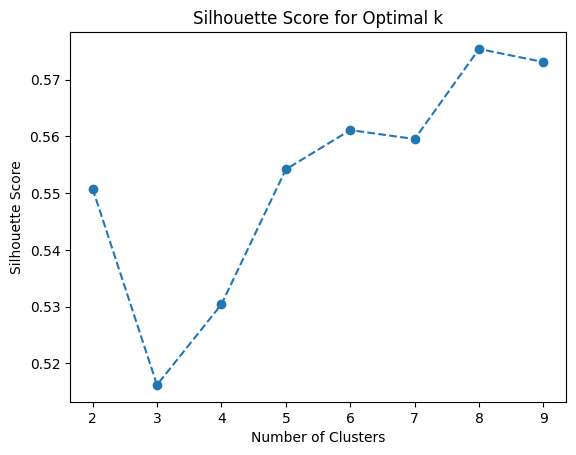

In [5]:
# Visualisasi Silhouette Score
plt.figure()
plt.plot(k_range, silhouette_scores, marker='o', linestyle='--')
plt.title('Silhouette Score for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Silhouette Score')
plt.show()

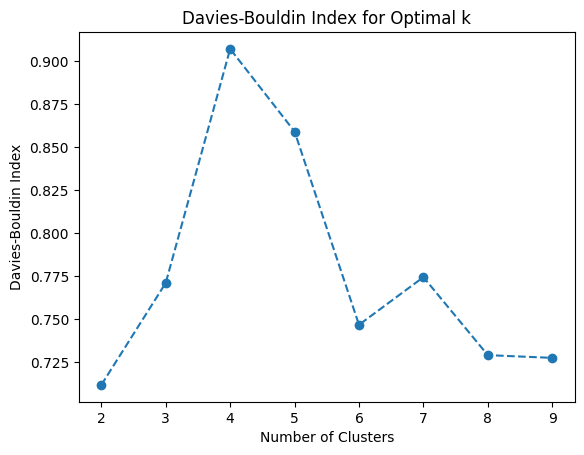

In [6]:
# Visualisasi Davies-Bouldin Index
plt.figure()
plt.plot(k_range, db_scores, marker='o', linestyle='--')
plt.title('Davies-Bouldin Index for Optimal k')
plt.xlabel('Number of Clusters')
plt.ylabel('Davies-Bouldin Index')
plt.show()

In [7]:
# Langkah 6: Klastering dengan jumlah cluster optimal
optimal_clusters = 3  # Pilih berdasarkan analisis
kmeans_model = KMeans(n_clusters=optimal_clusters, random_state=42, n_init=10)
cluster_labels = kmeans_model.fit_predict(data_normalized)

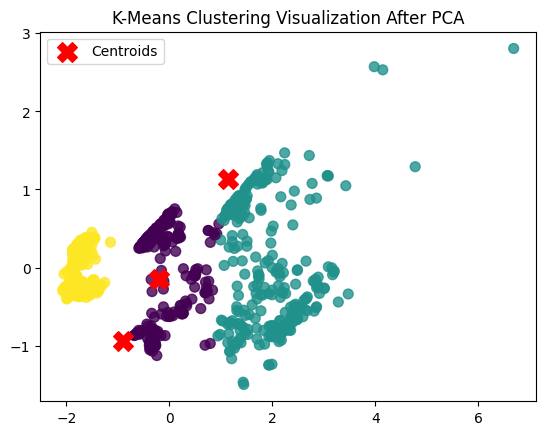

In [8]:
# Langkah 7: Visualisasi PCA
pca = PCA(n_components=2)
data_pca = pca.fit_transform(data_normalized)

plt.figure()
plt.scatter(data_pca[:, 0], data_pca[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.8)
plt.scatter(kmeans_model.cluster_centers_[:, 0], kmeans_model.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='Centroids')
plt.title("K-Means Clustering Visualization After PCA")
plt.legend()
plt.show()

In [9]:
# Langkah 8: Simpan hasil clustering ke file CSV
dataset['Cluster'] = cluster_labels
output_file_path = '/kaggle/working/submission.csv'
submission_data = dataset[['ID', 'Cluster']]
submission_data.to_csv(output_file_path, index=False)
print("Submission file saved to:", output_file_path)

Submission file saved to: /kaggle/working/submission.csv
